# 04 - Fake Review Identification & Trust Metrics

This notebook implements the Stage 4 analytics: identifying suspicious reviews using behavioral features and anomaly detection, and building a trust framework for reviewers and products.

## 1. Import Libraries and Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

input_path = "stage3_features.csv"

if os.path.exists(input_path):
    df = pd.read_csv(input_path)
    print(f"Loaded {len(df)} reviews with sentiment features.")
else:
    print(f"File not found: {input_path}")

df.head()

Loaded 69737 reviews with sentiment features.


,review_id,user_name,review_text,rating,helpful_votes,app_version,review_date,developer_reply,app_name,review_length,hour,cleaned_review,review_len,word_count,textblob_sentiment,vader_sentiment,norm_rating,norm_sentiment,sentiment_inconsistency
0,016bbd04-7f9c-4c2b-8f82-8d7cab4f424f,Sean Harris,"always happy with their service and goods,just...",5,0,32.4.0.100,2026-03-11 18:25:22,NaN,Amazon Shopping,97,18,"always happy with their service and goods,just...",97,18,0.750000,0.8845,1.00,0.94225,0.05775
1,7a6f39b1-5534-4eed-8100-1cdbedc5ea1e,Finn Fiechtner,pros and cons. 3 star review dead center. cons...,3,0,NaN,2026-03-11 18:15:01,NaN,Amazon Shopping,484,18,pros and cons. 3 star review dead center. cons...,484,82,0.141944,-0.6731,0.50,0.16345,0.33655
2,967d3ed1-6855-493d-8816-d7434a22180c,Bassam Yousre,the worst delivery service ever always not on ...,1,0,32.5.0.100,2026-03-11 18:08:16,NaN,Amazon Shopping,141,18,the worst delivery service ever always not on ...,141,26,-1.000000,-0.4215,0.00,0.28925,0.28925
3,9767efd5-66d8-4dc8-a86f-2c2a26bd0ee4,SO SUPO,happy,4,0,32.5.0.100,2026-03-11 17:57:29,NaN,Amazon Shopping,5,17,happy,5,1,0.800000,0.5719,0.75,0.78595,0.03595
4,26cf286d-c77c-4c64-ba92-dbb119a510fe,Steve Day,Says my phone is not compatible with tap to pa...,1,0,32.5.0.100,2026-03-11 16:45:46,NaN,Amazon Shopping,278,16,says my phone is not compatible with tap to pa...,278,51,0.550000,0.7184,0.00,0.85920,0.85920


## 2. Behavioral Feature Engineering
Fake reviews often follow behavioral patterns like high activity from a single user or ratings that deviate significantly from the norm.

In [4]:
print("Engineering behavioral features...")

# 1. Reviewer Activity: Number of reviews per user
df['reviewer_activity'] = df.groupby('user_name')['review_id'].transform('count')

# 2. Rating Deviation: How far the rating is from the product's average
df['product_avg_rating'] = df.groupby('app_name')['rating'].transform('mean')
df['rating_deviation'] = abs(df['rating'] - df['product_avg_rating'])

# 3. Extreme Rating Flag: 1 or 5 stars are often targets for manipulation
df['extreme_rating'] = df['rating'].apply(lambda x: 1 if x == 1 or x == 5 else 0)

print("Features engineered: reviewer_activity, rating_deviation, extreme_rating.")
df[['user_name', 'app_name', 'rating', 'reviewer_activity', 'rating_deviation']].head()

Engineering behavioral features...
Features engineered: reviewer_activity, rating_deviation, extreme_rating.


,user_name,app_name,rating,reviewer_activity,rating_deviation
0,Sean Harris,Amazon Shopping,5,1,2.2742
1,Finn Fiechtner,Amazon Shopping,3,1,0.2742
2,Bassam Yousre,Amazon Shopping,1,1,1.7258
3,SO SUPO,Amazon Shopping,4,1,1.2742
4,Steve Day,Amazon Shopping,1,1,1.7258


## 3. Heuristic Suspicion Scoring
We calculate a normalized suspicion score based on sentiment inconsistency, rating deviation, and reviewer activity.

In [5]:

activity_min = df['reviewer_activity'].min()
activity_max = df['reviewer_activity'].max()
df['norm_activity'] = (df['reviewer_activity'] - activity_min) / (activity_max - activity_min) if activity_max > activity_min else 0

df['norm_deviation'] = df['rating_deviation'] / 4

# Heuristic Suspicion Score: Weighted average of indicators
df['suspicion_score'] = (df['sentiment_inconsistency'] * 0.4) + \
                        (df['norm_deviation'] * 0.4) + \
                        (df['norm_activity'] * 0.2)

print("Heuristic suspicion score calculated.")

Heuristic suspicion score calculated.


## 4. Anomaly Detection 
Using unsupervised learning to find 'outlier' reviews across multiple feature dimensions.

In [6]:
features_for_model = ['sentiment_inconsistency', 'norm_activity', 'norm_deviation', 'extreme_rating']
X = df[features_for_model]

print("Training Isolation Forest for anomaly detection...")
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['anomaly_flag'] = iso_forest.fit_predict(X)


df['is_anomaly'] = df['anomaly_flag'].map({1: 0, -1: 1})

print(f"Anomalies detected: {df['is_anomaly'].sum()} reviews flagged.")

Training Isolation Forest for anomaly detection...
Anomalies detected: 3475 reviews flagged.


Anomalies detected: 3475 reviews flagged.


## 5. Intelligent Trust Framework
Quantifying trust at the reviewer and product level.

In [7]:
# 1. Reviewer Credibility Score 
reviewer_stats = df.groupby('user_name')['suspicion_score'].mean().reset_index()
reviewer_stats.columns = ['user_name', 'avg_suspicion']
reviewer_stats['credibility_score'] = 1 - reviewer_stats['avg_suspicion']

df = df.merge(reviewer_stats[['user_name', 'credibility_score']], on='user_name', how='left')

# 2. Product Trust Index 
product_stats = df.groupby('app_name').agg({
    'credibility_score': 'mean',
    'is_anomaly': 'mean'
}).reset_index()

product_stats['trust_index'] = product_stats['credibility_score'] * (1 - product_stats['is_anomaly'])

df = df.merge(product_stats[['app_name', 'trust_index']], on='app_name', how='left')

print("Trust Framework implemented: credibility_score & trust_index calculated.")

Trust Framework implemented: credibility_score & trust_index calculated.


## 6. Visualization and Results

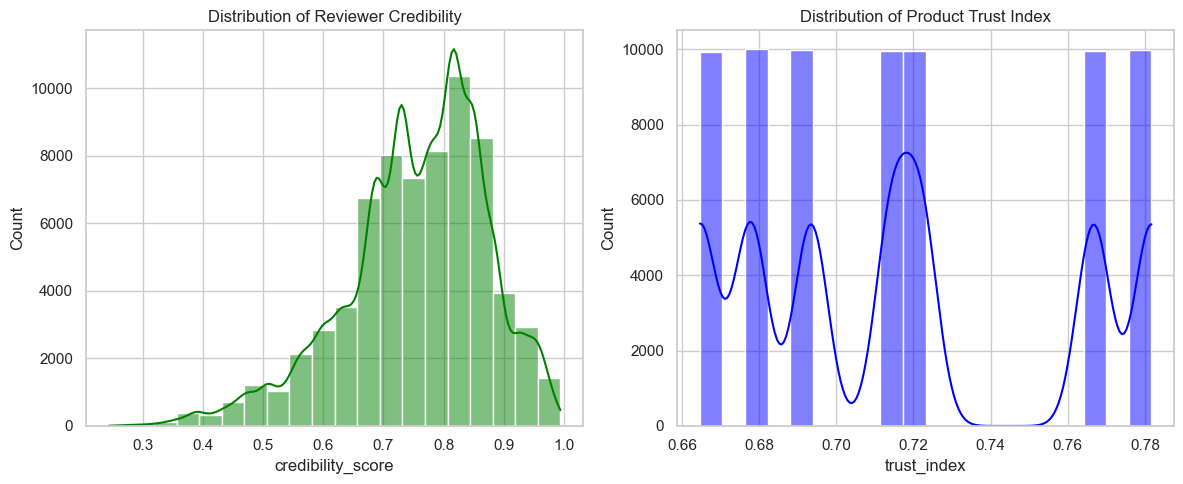

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['credibility_score'], bins=20, color='green', kde=True)
plt.title('Distribution of Reviewer Credibility')

plt.subplot(1, 2, 2)
sns.histplot(df['trust_index'], bins=20, color='blue', kde=True)
plt.title('Distribution of Product Trust Index')

plt.tight_layout()
plt.show()

In [9]:
print("Top 5 most suspicious reviews detected:")
df.sort_values(by='suspicion_score', ascending=False)[['user_name', 'app_name', 'rating', 'review_text', 'suspicion_score', 'is_anomaly']].head()

Top 5 most suspicious reviews detected:


,user_name,app_name,rating,review_text,suspicion_score,is_anomaly
49514,Aditya Sharma,Myntra,1,Extremely disappointed with the transparency o...,0.757362,1
49605,Neelofar Mushtaq -07,Myntra,1,I don't know what is wrong with myntra .. they...,0.756368,1
42152,Mintu Mondal,Myntra,1,"Dear Myntra Customer Support Team, I am writin...",0.745888,1
40900,Ashika Ashi,Myntra,1,The customer care experince is very bad of myn...,0.745208,1
7711,A Google user,Amazon Shopping,1,I have Prime. They still can not get things sh...,0.744400,1


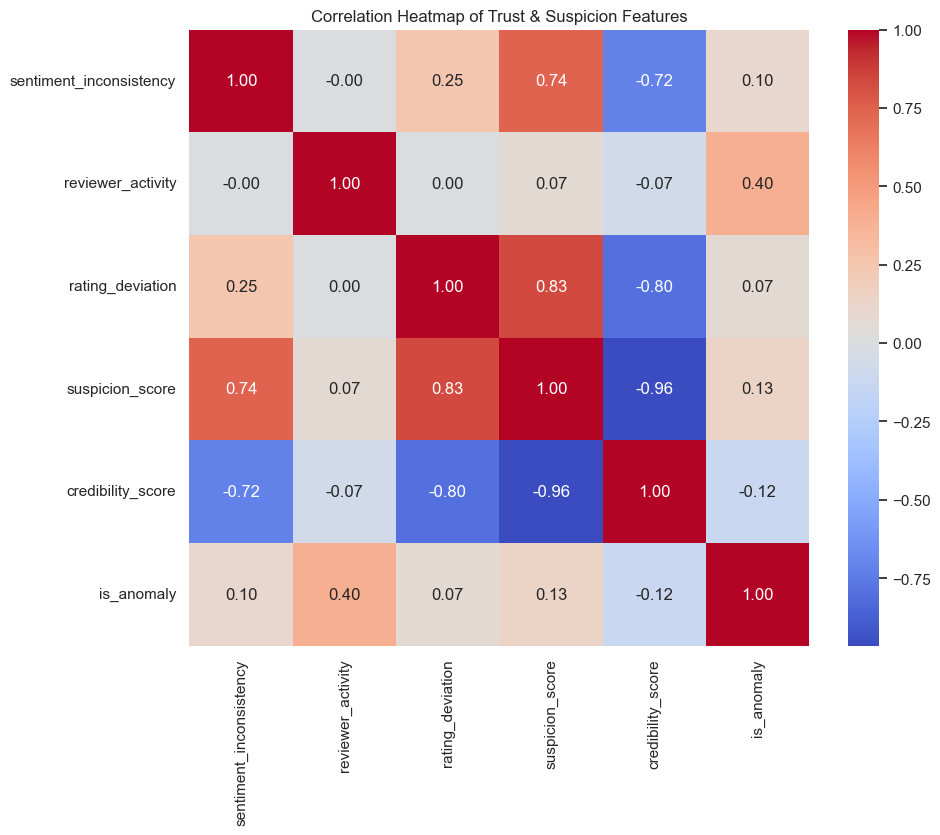

In [12]:

plt.figure(figsize=(10, 8))
corr = df[['sentiment_inconsistency', 'reviewer_activity', 'rating_deviation', 'suspicion_score', 'credibility_score', 'is_anomaly']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Trust & Suspicion Features")
plt.show()

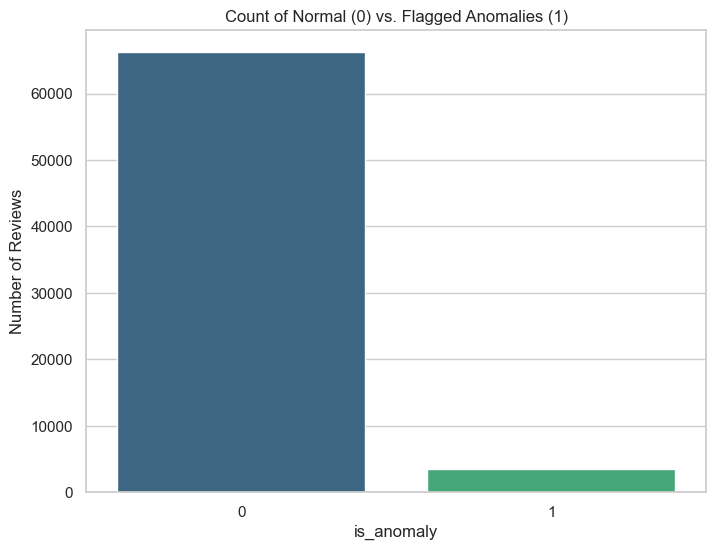

In [16]:

plt.figure(figsize=(8, 6))
sns.countplot(x='is_anomaly', data=df, hue='is_anomaly', palette='viridis', legend=False)
plt.title("Count of Normal (0) vs. Flagged Anomalies (1)")
plt.ylabel("Number of Reviews")
plt.show()

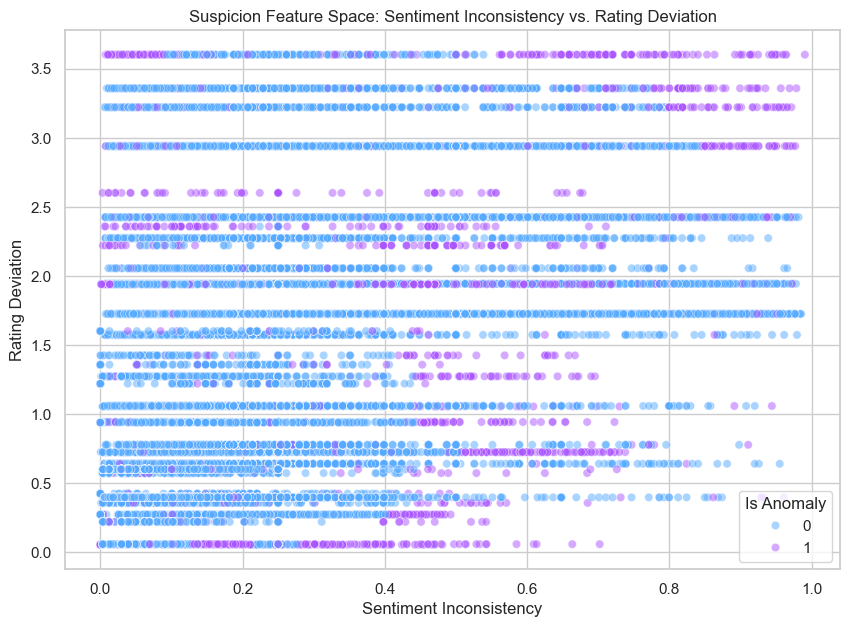

In [15]:

plt.figure(figsize=(10, 7))
sns.scatterplot(x='sentiment_inconsistency', y='rating_deviation', hue='is_anomaly', data=df, alpha=0.5, palette='cool')
plt.title("Suspicion Feature Space: Sentiment Inconsistency vs. Rating Deviation")
plt.xlabel("Sentiment Inconsistency")
plt.ylabel("Rating Deviation")
plt.legend(title='Is Anomaly')
plt.show()

## 7. Export Results

In [11]:
output_path = "stage4_results.csv"

df.to_csv(output_path, index=False)

print(f"Saved {len(df)} records with suspicion and trust metrics to {output_path}")

Saved 69737 records with suspicion and trust metrics to stage4_results.csv
